In [6]:
import arrow
import os
import pathlib
import re
import h5py

import numpy as np
import scipy as sp
import pandas as pd
import xarray as xr
import netCDF4 as nc

import matplotlib.pyplot as plt

from tqdm import tqdm


In [7]:
copernicus_base = "/users/tom/copernicus"
maria_base = "/users/tom/maria"

regions = pd.read_csv(f"{copernicus_base}/regions.csv", index_col=0).fillna("")
regions = regions.loc[regions.include_in_maria]
regions

,description,country,notes,latitude,grid_latitude,longitude,grid_longitude,altitude,min_altitude,max_altitude,...,meteostat_id,include_in_maria,hourly_single_start,hourly_single_end,hourly_levels_start,hourly_levels_end,monthly_single_start,monthly_single_end,monthly_levels_start,monthly_levels_end
algonquin,"Algonquin Provincial Park, Ontario",Canada,Algonquin Radio Observatory,45.955500,46.00,-78.073000,-78.00,350,0,1000,...,ERA5,True,,2025,2020.0,2025,,2025,2020.0,2025
boolardy,"Boolardy, Western Australia",Australia,"MRO, SKA",-26.697000,-26.75,116.631000,116.75,395,250,500,...,94422,True,,2025,2010.0,2025,,2025,2000.0,2025
chajnantor,"Llano de Chajnantor, Antofagasta",Chile,"ACT, ALMA, APEX, SO, TAO",-23.006000,-23.00,-67.759000,-67.75,5000,4000,6000,...,ESO,True,,2025,1950.0,2100,2000.0,2025,1940.0,2030
chiang_mai,"Chiang Mai, Thailand",Thailand,TNRT,18.864000,18.75,99.217000,99.25,395,0,2000,...,,True,,2025,2023.0,2025,,2025,2010.0,2025
dominion,"Kaleden, British Columbia",Canada,Dominion Radio Astrophysical Observatory,49.320751,49.25,-119.620811,-119.50,545,0,1000,...,ERA5,True,,2025,2020.0,2025,,2025,2020.0,2025
effelsberg,"Effelsberg, North Rhine-Westphalia",Germany,ERT,50.524000,50.50,6.883000,7.00,319,0,500,...,10506,True,,2025,2015.0,2025,,2025,2000.0,2025
green_bank,"Green Bank, West Virginia",USA,Green Bank Observatory,38.433000,38.50,-79.840000,-79.75,807,500,1500,...,72417,True,,2025,2000.0,2025,,2025,1940.0,2025
kitt_peak,"Kitt Peak, Arizona",USA,Kitt Peak Observatory,31.965000,32.00,-111.599000,-111.50,2096,768,2016,...,,True,,2025,2020.0,2025,,2025,2010.0,2025
mauna_kea,"Mauna Kea, Hawaii",USA,Mauna Kea Observatory,19.823000,19.75,-155.475000,-155.50,4205,3500,4500,...,MKWC,True,,2025,2000.0,2025,,2025,1940.0,2025
meerkat,"Meerkat National Park, Northern Cape",South Africa,"HERA, MeerKAT, SKA",-30.713000,-30.75,21.443000,21.50,1075,750,1250,...,ERA5,True,,2025,2010.0,2025,,2025,1980.0,2025


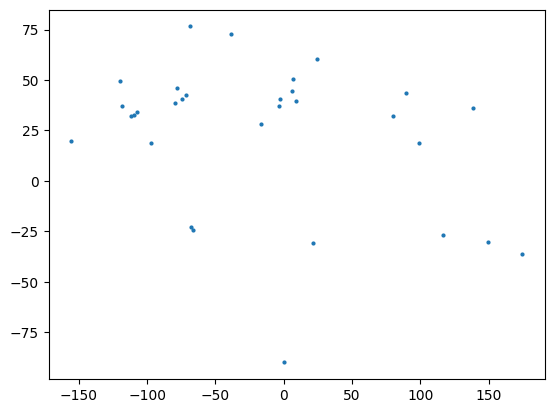

In [8]:
plt.scatter(regions.longitude, regions.latitude, s=4)

In [9]:
metadata = ["number",
             "time",
             "step",
             "isobaricInhPa",
             "latitude",
             "longitude",
             "valid_time"]

translation = {
            "z"    : "geopotential", # m
            "r"    : "humidity", # [none]
            "t"    : "temperature", # K
            "u"    : "wind_east", # m s^-1
            "v"    : "wind_north", # m s^-1
            "ciwc" : "cloud_ice_water", # kg m^-3
            "clwc" : "cloud_liquid_water", # kg m^-3
            "cswc" : "cloud_snow_water", # kg m^-3
            "crwc" : "cloud_rain_water", # kg m^-3
            "cc"   : "cloud_cover", # [none]
            "o3"   : "ozone", # kg m^-3
            "d"    : "divergence",
            "pv"   : "potential_vorticity",
            "vo"   : "relative_vorticity",
            "w"    : "wind_vertical",
            }

In [11]:
# q_bounds = np.array([0.01, 0.99])
# x_bounds = np.sqrt(2) * sp.special.erfinv(2 * q_bounds - 1)
# x = [-np.inf, *np.linspace(*p_bounds, 9), np.inf]
# quantiles = 0.5 * (1 + sp.special.erf(x / np.sqrt(2)))
# quantiles

In [13]:
from tqdm import trange




for region, region_data in regions.iterrows():

    write_path = f"{maria_base}/data/atmosphere/weather/era5/v2/{region}.h5"

    if os.path.exists(write_path) and region != "chajnantor":
        continue

    data = {}
    compiled_file = f"{copernicus_base}/era5/compiled/{region}.h5"
    
    with h5py.File(compiled_file, "r") as f:
        for group in f.keys():
            data[group] = {}
            for key in f[group].keys():
                data[group][key] = f[group][key][:]

    year_day_bins = np.linspace(0, 366, 26)
    day_hour_bins = np.linspace(0, 24, 25)
    
    n_year_day_bins = len(year_day_bins) - 1
    n_day_hour_bins = len(day_hour_bins) - 1
    
    year_day_index = np.digitize(data["metadata"]["year_day"], year_day_bins) - 1
    day_hour_index = np.digitize(data["metadata"]["day_hour"], day_hour_bins) - 1
    
    quantiles = [0., 0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99, 1.]
    
    n_levels = len(data["metadata"]["pressure"])
    
    qdata = {"single": {}, "levels": {}}
    for key in data["single"]:
        qdata["single"][key] = np.nan + np.empty((len(quantiles),
                                                  n_year_day_bins, 
                                                  n_day_hour_bins, 
                                                 ))
    
    for key in data["levels"]:
        qdata["levels"][key] = np.nan + np.empty((len(quantiles),
                                                  n_year_day_bins, 
                                                  n_day_hour_bins, 
                                                  n_levels,
                                                  ))


    pbar = trange(n_year_day_bins, desc=region)
    
    for _year_day_index in pbar:
    
        year_day_dist = np.abs((year_day_index - _year_day_index + n_year_day_bins / 2) % n_year_day_bins - n_year_day_bins / 2)
        year_day_mask = year_day_dist < 2
    
        for _day_hour_index in range(n_day_hour_bins):

            pbar.set_postfix(day_hour_index=_day_hour_index)
    
            day_hour_dist = np.abs((day_hour_index - _day_hour_index + n_day_hour_bins / 2) % n_day_hour_bins - n_day_hour_bins / 2)
            day_hour_mask = day_hour_dist < 2
            
            mask = year_day_mask & day_hour_mask
    
            if not mask.sum():
                continue
            
            for key in data["single"]:
                W = (np.exp(-year_day_dist) * np.exp(-day_hour_dist))
                qdata["single"][key][:, _year_day_index, _day_hour_index] = np.nanquantile(data["single"][key][mask], 
                                                                                        q=quantiles, axis=0,
                                                                                        method="inverted_cdf",
                                                                                        weights=W[mask])
    
            for key in data["levels"]:
                W = (np.exp(-year_day_dist) * np.exp(-day_hour_dist))[:, None] * np.ones(n_levels)
                qdata["levels"][key][:, _year_day_index, _day_hour_index] = np.nanquantile(data["levels"][key][mask], 
                                                                                        q=quantiles, axis=0,
                                                                                        method="inverted_cdf",
                                                                                        weights=W[mask])
    
    year_day_side = 0.5 * (year_day_bins[1:] + year_day_bins[:-1])
    year_day_side = [year_day_side[-1] - 366, *year_day_side, year_day_side[0] + 366]
    
    day_hour_side = 0.5 * (day_hour_bins[1:] + day_hour_bins[:-1])
    day_hour_side = [day_hour_side[-1] - 24, *day_hour_side, day_hour_side[0] + 24]

# divergence s**-1
# cloud_cover (0 - 1)
# geopotential m**2 s**-2
# ozone kg kg**-1
# potential_vorticity K m**2 kg**-1 s**-1
# humidity %
# cloud_ice_water kg kg**-1
# cloud_liquid_water kg kg**-1
# cloud_rain_water kg kg**-1
# cloud_snow_water kg kg**-1
# temperature K
# wind_east m s**-1
# wind_north m s**-1
# wind_vertical Pa s**-1
# relative_vorticity s**-1
    
    fields_to_write = {"cloud_cover": {"log": True, "units": ""},
                       "cloud_ice_water": {"log": True, "units": "kg m^-3"},
                       "cloud_liquid_water": {"log": True, "units": "kg m^-3"},
                       "cloud_rain_water": {"log": True, "units": "kg m^-3"},
                       "cloud_snow_water": {"log": True, "units": "kg m^-3"},
                       "divergence": {"log": False, "units": "s^-1"},
                       "geopotential": {"log": False, "units": "m^2 s^-2"},
                       "humidity": {"log": True, "units": ""},
                       "ozone": {"log": True, "units": "kg m^-3"},
                       "potential_vorticity": {"log": False, "units": " K m^2 kg^-1 s^-1"},
                       "relative_vorticity": {"log": False, "units": "s^-1"},
                       "temperature": {"log": False, "units": "K"},
                       "wind_east": {"log": False, "units": "m s^-1"},
                       "wind_north": {"log": False, "units": "m s^-1"},
                       "wind_speed": {"log": True, "units": "m s^-1"},
                       "wind_vertical": {"log": False, "units": "Pa s^-1"}}
    
    with h5py.File(write_path, "w") as f:
    
        f.create_group("metadata")
        f["metadata"].create_dataset("side_year_day", data=0.5 * (year_day_bins[1:] + year_day_bins[:-1]))
        f["metadata"].create_dataset("side_day_hour", data=0.5 * (day_hour_bins[1:] + day_hour_bins[:-1]))
        f["metadata"].create_dataset("side_pressure", data=data["metadata"]["pressure"])
        f["metadata"].create_dataset("side_quantile", data=quantiles)
        
        f.create_group("levels")
        for key in qdata["levels"]:
    
            if key not in fields_to_write: 
                continue
    
            if (qdata["levels"][key] > 0).all():
                values = np.where(qdata["levels"][key] > 0, qdata["levels"][key], qdata["levels"][key][qdata["levels"][key] > 0].min())
                f["levels"].create_dataset(key, 
                                           data=np.log(values), 
                                           dtype=np.float32)
                f["levels"][key].attrs["log"] = True
                
            else:
                f["levels"].create_dataset(key, 
                                           data=qdata["levels"][key], 
                                           dtype=np.float32)
                f["levels"][key].attrs["log"] = False

            f["levels"][key].attrs["units"] = fields_to_write[key]["units"]
    
            

yebes: 100%|█████████████████| 25/25 [00:27<00:00,  1.08s/it, day_hour_index=23]


In [15]:
qdata["single"].keys()

dict_keys(['cloud_cover', 'pwv', 'total_ice_water', 'total_liquid_water', 'total_rain_water', 'total_snow_water'])

In [20]:
qdata["levels"]["temperature"].shape

(11, 25, 24, 37)

In [71]:
region = "san_basilio"

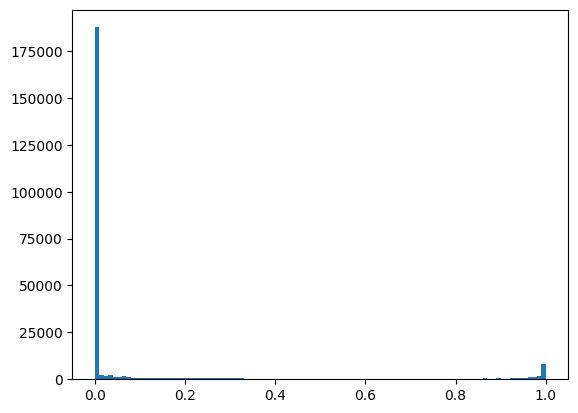

In [88]:
plt.hist(qdata["levels"]["cloud_cover"].ravel(), bins=100)
plt.show()

In [83]:
for key in qdata["levels"]:
    print(key, qdata["levels"][key].min(), qdata["levels"][key].max())

air_density 0.0012288995762614928 1.2699540436833812
cloud_cover -5.551115123125783e-17 1.0
cloud_ice_water -6.373178404594571e-20 0.00029342048165224973
cloud_liquid_water -6.606077477959514e-20 0.0009500499922322428
cloud_rain_water -1.4663117175622632e-20 0.0004038965152336231
cloud_snow_water -1.2931070400888942e-19 0.0014365404627657546
divergence -0.0004838493186980486 0.0004522884264588356
geopotential -1365.222656250029 480130.5625
humidity 1e-08 1.0
ozone 4.036748950470955e-09 6.263973520611212e-07
potential_vorticity -0.0053469352424144745 0.02368803322315216
relative_vorticity -0.000447138212621212 0.0009149743709713221
temperature 193.61538696289062 315.993408203125
water_vapor 1.3976039726385676e-13 0.026770497788879886
wind_east -83.72660827636719 151.2515411376953
wind_north -105.56356811523438 82.13632202148438
wind_speed 0.009539684491063408 152.26765350888417
wind_vertical -4.879770278930664 5.454557418823242


In [96]:
keys_to_write = {"cloud_cover": {"log": True},
                 "cloud_ice_water": {"log": True},
                 "cloud_liquid_water": {"log": True},
                 "cloud_rain_water": {"log": True},
                 "cloud_snow_water": {"log": True},
                 "divergence": {"log": False},
                 "geopotential": {"log": False},
                 "humidity": {"log": True},
                 "ozone": {"log": True},
                 "potential_vorticity": {"log": False},
                 "relative_vorticity": {"log": False},
                 "temperature": {"log": False},
                 # "water_vapor": {"log": False},
                 "wind_east": {"log": False},
                 "wind_north": {"log": False},
                 "wind_speed": {"log": True},
                 "wind_vertical": {"log": False}}

with h5py.File(f"{maria_base}/data/atmosphere/weather/era5/v2/{region}.h5", "w") as f:

    f.create_group("metadata")
    f["metadata"].create_dataset("side_year_day", data=0.5 * (year_day_bins[1:] + year_day_bins[:-1]))
    f["metadata"].create_dataset("side_day_hour", data=0.5 * (day_hour_bins[1:] + day_hour_bins[:-1]))
    f["metadata"].create_dataset("side_pressure", data=data["metadata"]["pressure"])
    f["metadata"].create_dataset("side_quantile", data=quantiles)
    
    f.create_group("levels")
    for key in qdata["levels"]:

        if key not in keys_to_write: 
            continue

        if (qdata["levels"][key] > 0).all():
            values = np.where(qdata["levels"][key] > 0, qdata["levels"][key], qdata["levels"][key][qdata["levels"][key] > 0].min())
            f["levels"].create_dataset(key, 
                                       data=np.log(values), 
                                       dtype=np.float32)
            f["levels"][key].attrs["log"] = True
            
        else:
            f["levels"].create_dataset(key, 
                                       data=qdata["levels"][key], 
                                       dtype=np.float32)
            f["levels"][key].attrs["log"] = False

            
        print(key)
        

cloud_cover
cloud_ice_water
cloud_liquid_water
cloud_rain_water
cloud_snow_water
divergence
geopotential
humidity
ozone
potential_vorticity
relative_vorticity
temperature
wind_east
wind_north
wind_speed
wind_vertical


In [81]:
qdata["levels"]["humidity"].min()

np.float64(1e-08)

In [78]:
{key: {"log": False} for key in qdata["levels"].keys()}

{'air_density': {'log': False},
 'cloud_cover': {'log': False},
 'cloud_ice_water': {'log': False},
 'cloud_liquid_water': {'log': False},
 'cloud_rain_water': {'log': False},
 'cloud_snow_water': {'log': False},
 'divergence': {'log': False},
 'geopotential': {'log': False},
 'humidity': {'log': False},
 'ozone': {'log': False},
 'potential_vorticity': {'log': False},
 'relative_vorticity': {'log': False},
 'temperature': {'log': False},
 'water_vapor': {'log': False},
 'wind_east': {'log': False},
 'wind_north': {'log': False},
 'wind_speed': {'log': False},
 'wind_vertical': {'log': False}}

In [49]:
np.nanquantile(data["single"][key][mask], 
                                                                                        q=quantiles, axis=0,
                                                                                        method="inverted_cdf",
                                                                                        weights=W[mask]).shape

(11,)

In [63]:
for key in qdata["levels"]:

    print(key, (qdata["levels"][key] > 0).all())

air_density True
cloud_cover False
cloud_ice_water False
cloud_liquid_water False
cloud_rain_water False
cloud_snow_water False
divergence False
geopotential False
humidity True
ozone True
potential_vorticity False
relative_vorticity False
temperature True
water_vapor True
wind_east False
wind_north False
wind_speed True
wind_vertical False


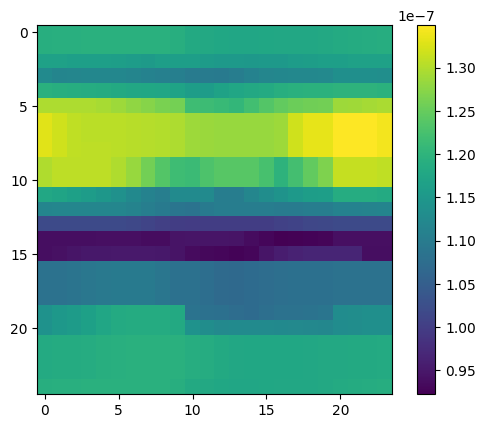

In [57]:
plt.imshow(qdata["levels"]["ozone"][-1, ..., 0])
plt.colorbar()

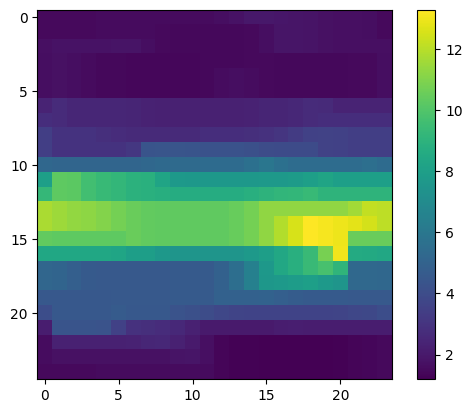

In [20]:
plt.imshow(qdata["single"]["pwv"][..., 0])
plt.colorbar()

air_density
cloud_cover
cloud_ice_water
cloud_liquid_water
cloud_rain_water
cloud_snow_water
divergence
geopotential
humidity
ozone
potential_vorticity
relative_vorticity
temperature
water_vapor
wind_east
wind_north
wind_speed
wind_vertical


In [28]:
0.5 * (year_day_bins[1:] + year_day_bins[:-1])

array([  7.32,  21.96,  36.6 ,  51.24,  65.88,  80.52,  95.16, 109.8 ,
       124.44, 139.08, 153.72, 168.36, 183.  , 197.64, 212.28, 226.92,
       241.56, 256.2 , 270.84, 285.48, 300.12, 314.76, 329.4 , 344.04,
       358.68])

In [50]:
qdata["levels"].keys()

dict_keys(['air_density', 'cloud_cover', 'cloud_ice_water', 'cloud_liquid_water', 'cloud_rain_water', 'cloud_snow_water', 'divergence', 'geopotential', 'humidity', 'ozone', 'potential_vorticity', 'relative_vorticity', 'temperature', 'water_vapor', 'wind_east', 'wind_north', 'wind_speed', 'wind_vertical'])

In [54]:
np.median(qdata["levels"]["ozone"][..., quantiles.index(0.5)], axis=(0, 1))

array([1.10820199e-07, 1.09161938e-07, 1.08451516e-07, 1.04345681e-07,
       1.01084648e-07, 9.82699575e-08, 9.53079571e-08, 9.22891843e-08,
       8.92135006e-08, 8.64835918e-08, 8.40929637e-08, 7.96523310e-08,
       7.62282042e-08, 7.29632745e-08, 6.93619668e-08, 6.56140102e-08,
       6.17259559e-08, 5.88329740e-08, 5.91395928e-08, 6.62631727e-08,
       9.00877453e-08, 1.16235906e-07, 1.47127224e-07, 1.68695721e-07,
       1.75396991e-07, 1.76536048e-07, 1.94647477e-07, 3.14186352e-07,
       3.61329541e-07, 3.55485341e-07, 3.05846584e-07, 1.87647061e-07,
       1.33948362e-07, 8.54050128e-08, 4.25299227e-08, 2.14125047e-08,
       6.45260445e-09])

In [16]:
qdata["single"].keys()

dict_keys(['cloud_cover', 'pwv', 'total_ice_water', 'total_liquid_water', 'total_rain_water', 'total_snow_water'])

In [128]:
data[region]["levels"][key].shape

(87672, 36)

In [129]:
    qdata[region] = {}
    qdata[region]["levels"] = {}

(87672, 1)

In [120]:
for key in data[region]["levels"]:
    print(key)

geopotential
humidity
temperature
wind_east
wind_north
cloud_ice_water
cloud_liquid_water
cloud_snow_water
cloud_rain_water
cloud_cover
ozone
divergence
potential_vorticity
relative_vorticity
wind_vertical
z
wind_speed
water_vapor
air_density


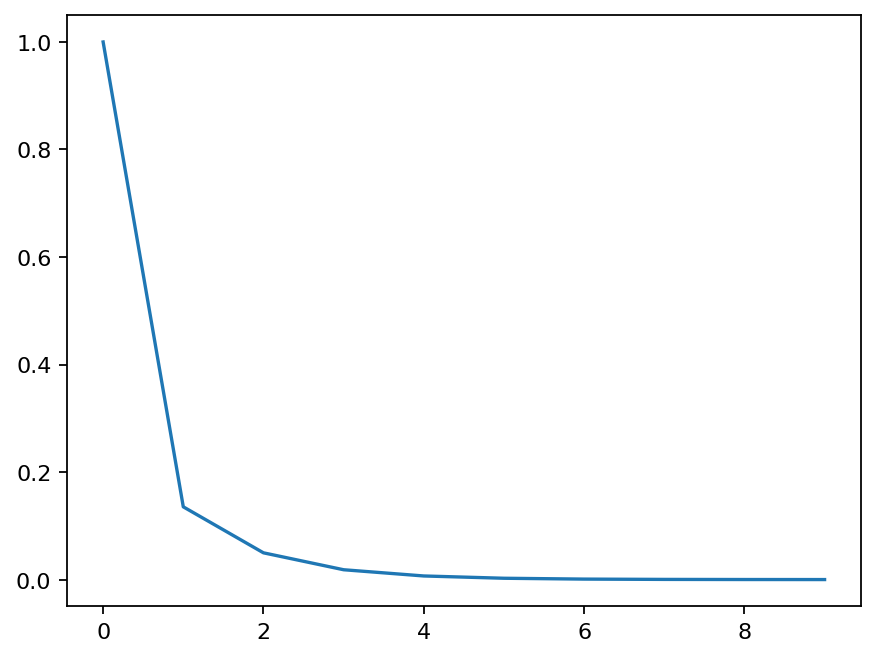

In [118]:
W = np.exp(-year_day_dist) * np.exp(-day_hour_dist)


plt.plot(W[:10])

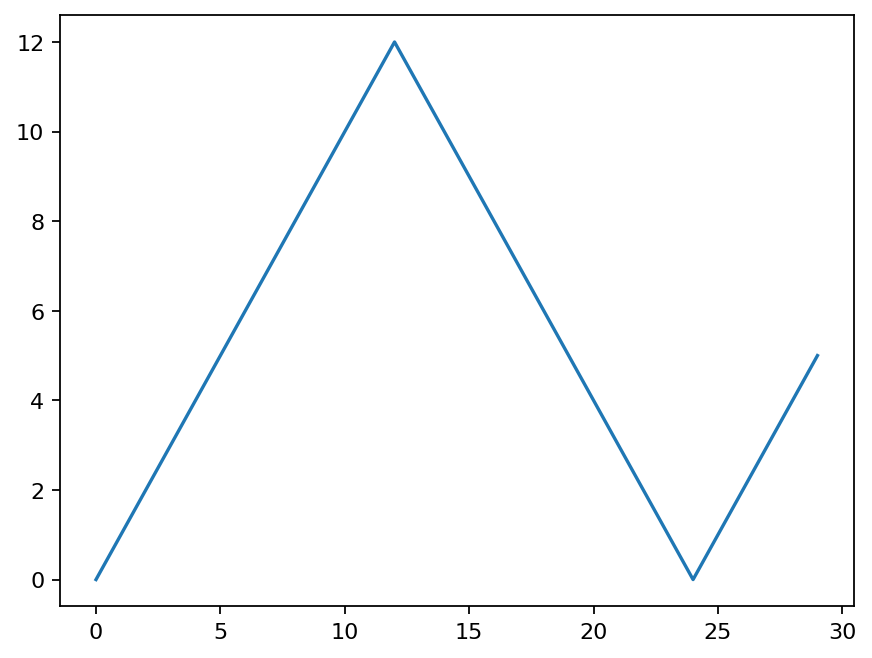

In [110]:
plt.plot(day_hour_dist[:30])

In [81]:
year_day_dist = data[region]["metadata"]["year_day"] - year_day_side[:, None]

array([[ 3.64979167e+02,  2.08333333e-02,  6.25000000e-02, ...,
         3.65854167e+02,  3.65895833e+02,  3.65937500e+02],
       [ 3.50339167e+02, -1.46191667e+01, -1.45775000e+01, ...,
         3.51214167e+02,  3.51255833e+02,  3.51297500e+02],
       [ 3.35699167e+02, -2.92591667e+01, -2.92175000e+01, ...,
         3.36574167e+02,  3.36615833e+02,  3.36657500e+02],
       ...,
       [ 4.28991667e+01, -3.22059167e+02, -3.22017500e+02, ...,
         4.37741667e+01,  4.38158333e+01,  4.38575000e+01],
       [ 2.82591667e+01, -3.36699167e+02, -3.36657500e+02, ...,
         2.91341667e+01,  2.91758333e+01,  2.92175000e+01],
       [ 1.36191667e+01, -3.51339167e+02, -3.51297500e+02, ...,
         1.44941667e+01,  1.45358333e+01,  1.45775000e+01]],
      shape=(25, 87672))

In [76]:
W = 

14.076923076923077

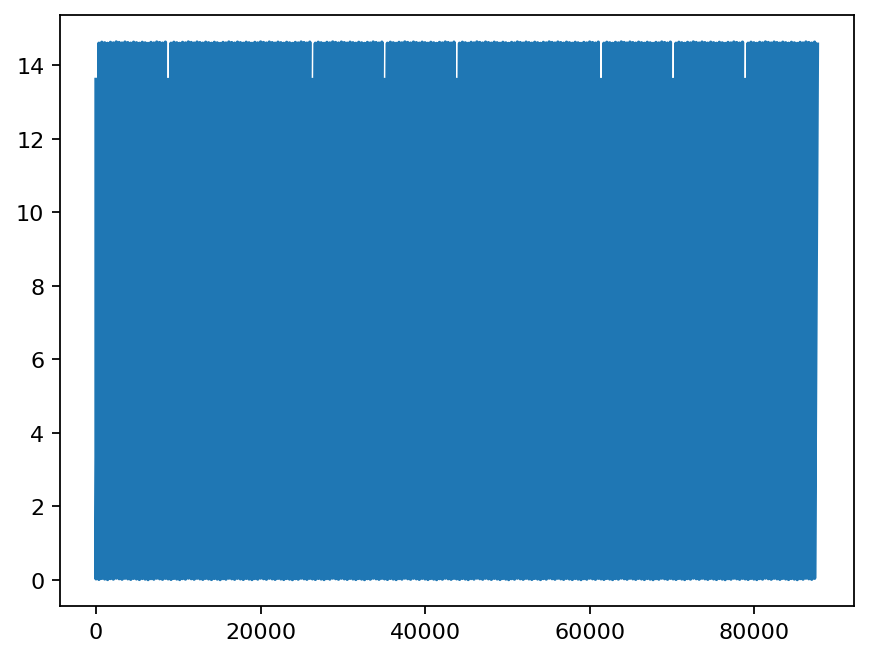

In [75]:
plt.plot(year_day_part)

In [67]:
data[region]["metadata"]["year_day"].max()

np.float64(365.9791666666667)

In [68]:
data[region]["metadata"]["year_day"] - year_day_side[year_day_index]

array([13.97916667,  0.02083333,  0.0625    , ..., 14.85416667,
       14.89583333, 14.9375    ], shape=(87672,))

In [5]:
for k, v in data[region].items():
    if k in use_profile_variables:  
        if np.isnan(np.atleast_1d(v)).any():
            raise ValueError(f"NaN in {region}:{k}")
        data[region][k] = data[region][k][isort]


NameError: name 'use_profile_variables' is not defined

In [56]:
import pytz
import logging

logger = logging.getLogger()

min_date = arrow.get(data["metadata"]["timestamp"].min() + 3600).astimezone(pytz.utc).ctime()
max_date = arrow.get(data["metadata"]["timestamp"].max() + 3600).astimezone(pytz.utc).ctime()
logger.info(f"min_time = {min_date}")
logger.info(f"max_time = {max_date}")

# data["levels"]["wind_speed"] = np.sqrt(data[region]["levels"]["wind_east"]**2 + data[region]["levels"]["wind_north"]**2 + data[region]["levels"]["wind_vertical"]**2)


In [57]:
min_date, max_date

('Thu Jan  2 00:30:00 2020', 'Thu May  7 23:30:00 2026')

In [ ]:


n_times = len(data[region]["time"])
n_levels = len(data[region]["pressure_levels"])
n_quantiles = len(quantiles)

quantile_data[region] = {}

pbar = tqdm([*use_profile_variables, *derived_variables], desc=f"computing quantiles for {region}")

for v in pbar:

    pbar.set_postfix(variable=v)

    quantile_data[region][v] = np.zeros((n_yd, n_dh, n_quantiles, n_levels))

    yd_bin_index = np.digitize(data[region]["year_day"], yd_bins) - 1
    dh_bin_index = np.digitize(data[region]["day_hour"], dh_bins) - 1
    
    for uydbi in np.unique(yd_bin_index):
        yd_mask = yd_bin_index == uydbi
        for udhbi in np.unique(dh_bin_index):
            mask = yd_mask & (dh_bin_index == udhbi)
            
            quantile_data[region][v][uydbi, udhbi] = np.quantile(data[region][v][mask], q=quantiles, axis=0)
